# Task 5 - Feature Importance

**Objective:**
Find most important factors affecting GPA

**Tasks:**
- Load Random Forest & XGBoost models
- Extract feature importance
- Create bar chart
- Rank features

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming xgboost is available if the model was saved
import xgboost

feature_cols = [
    "Study_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day"
]

# Load models
with open('../../models/random_forest_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

with open('../../models/xgboost_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

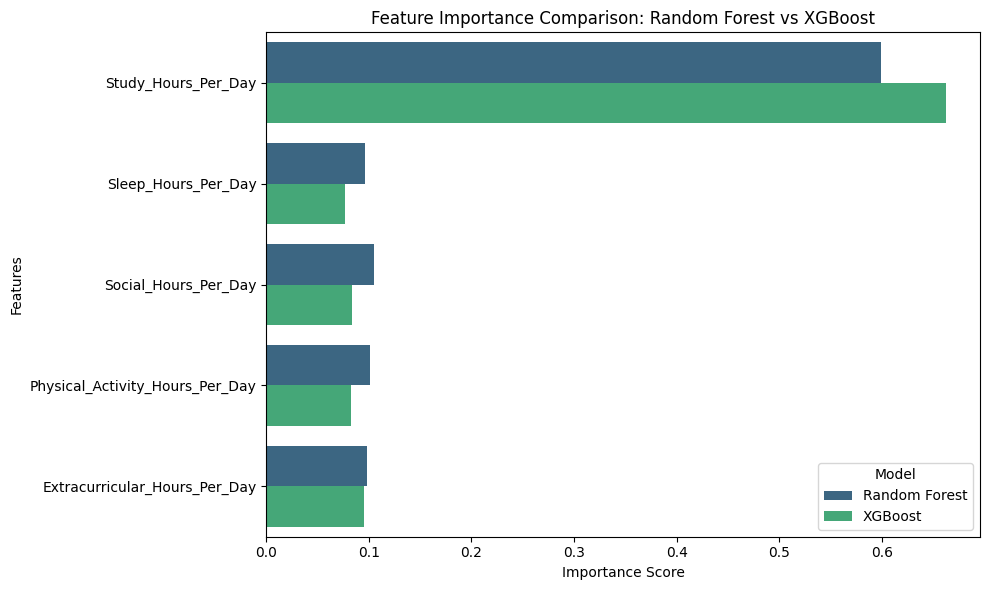

In [2]:
# Extract Feature Importances
rf_importances = rf_model.feature_importances_
xgb_importances = xgb_model.feature_importances_

# Create DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances
})

# Melt the dataframe for seaborn plotting
importance_melted = importance_df.melt(id_vars='Feature', var_name='Model', value_name='Importance')

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_melted, x='Importance', y='Feature', hue='Model', palette='viridis')
plt.title('Feature Importance Comparison: Random Forest vs XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

In [3]:
# Rank features based on average importance across both models for a unified ranking
importance_df['Average Importance'] = importance_df[['Random Forest', 'XGBoost']].mean(axis=1)
ranked_df = importance_df.sort_values(by='Average Importance', ascending=False).reset_index(drop=True)

print("Ranked Feature List (by Average Importance):")
display(ranked_df[['Feature', 'Random Forest', 'XGBoost', 'Average Importance']])

Ranked Feature List (by Average Importance):


,Feature,Random Forest,XGBoost,Average Importance
0,Study_Hours_Per_Day,0.599105,0.662605,0.630855
1,Extracurricular_Hours_Per_Day,0.098529,0.094964,0.096747
2,Social_Hours_Per_Day,0.105235,0.083277,0.094256
3,Physical_Activity_Hours_Per_Day,0.101091,0.082610,0.091850
4,Sleep_Hours_Per_Day,0.096040,0.076544,0.086292


### Conclusion

**Explanation:**
Based on feature importance from both Random Forest and XGBoost, Study_Hours_Per_Day is by far the most significant factor affecting GPA, contributing more than 60% of the model’s decision-making. All other variables, including sleep, social, extracurricular, and physical activity, have relatively low and similar importance, indicating minimal impact. This confirms earlier findings from EDA and model results that academic performance is primarily driven by study time.